In [ ]:
import pandas as pd
#from google.colab import files
#uploaded = files.upload()

#df = pd.read_excel()
df = pd.read_excel("coffee shop sale.xlsx")
df

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino


In [ ]:
#Understand your data and verify successful import
df.dtypes
#df.describe
#df.head()
#df.tail()

,0
transaction_id,int64
transaction_date,datetime64[ns]
transaction_time,object
transaction_qty,int64
store_id,int64
store_location,object
product_id,int64
unit_price,float64
product_category,object
product_type,object


In [ ]:
#Transaction count by product category
df.groupby('product_category')['transaction_qty'].count().sort_values(ascending=False)

,transaction_qty
product_category,
Coffee,58416
Tea,45449
Bakery,22796
Drinking Chocolate,11468
Flavours,6790
Coffee beans,1753
Loose Tea,1210
Branded,747
Packaged Chocolate,487


In [ ]:
#Transaction count by store location
df.groupby('store_location')['transaction_qty'].count().sort_values(ascending=False)

,transaction_qty
store_location,
Hell's Kitchen,50735
Astoria,50599
Lower Manhattan,47782


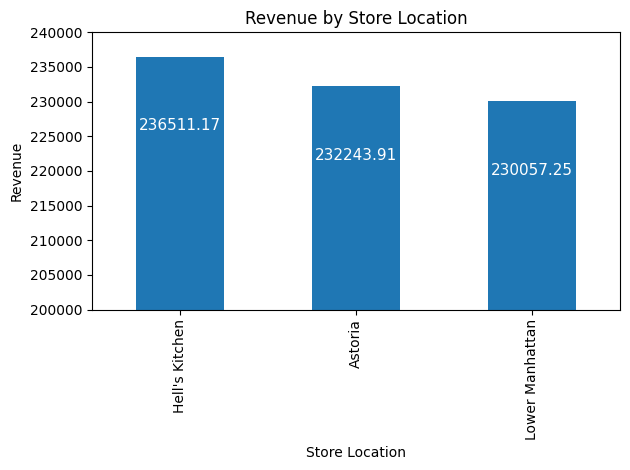

In [ ]:
#Add Revenue as a column in df
df["Revenue"]=df["transaction_qty"]*df["unit_price"]
import matplotlib.pyplot as plt
#find sum of revenue per store location
revenuebySL=df.groupby('store_location')['Revenue'].sum().sort_values(ascending=False)
#bar plot for revenue by store location
revenuebySL.plot(kind='bar')
plt.title("Revenue by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Revenue")
plt.tight_layout()
for i, value in enumerate(revenuebySL):
    plt.text(i, value - 10000, f"{value:.2f}", ha='center', va = 'center',fontsize=11, color = 'white')
plt.ylim(200000,240000)
plt.show()

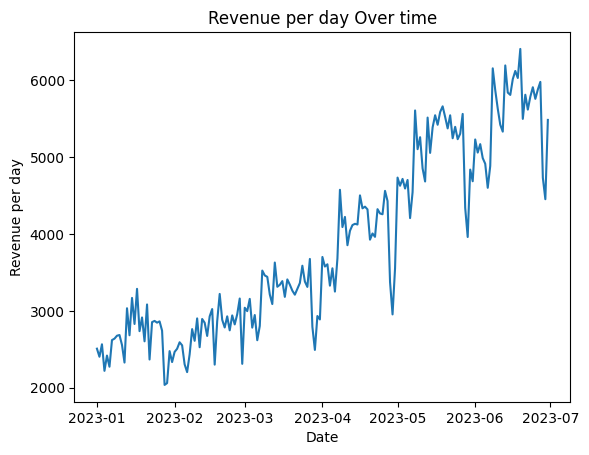

<Figure size 1000x500 with 0 Axes>

In [ ]:
#Line graph for revenue over time
daily_revenue = df.groupby('transaction_date')['Revenue'].sum()
plt.plot(daily_revenue.index, daily_revenue.values)
plt.xlabel("Date")
plt.ylabel("Revenue per day")
plt.title("Revenue per day Over time")
plt.figure(figsize=(10,5))
plt.show()
plt.show()

In [1]:

#Find daily revenue

daily_rev = df.groupby("transaction_date")["Revenue"].sum().reset_index()

daily_rev = daily_rev.sort_values("transaction_date")

# Calculate change in revenue from previous day.
daily_rev["Rev_Change"] = daily_rev["Revenue"].diff()
rev_drops = daily_rev[daily_rev["Rev_Change"] < 0]
top_10_drops = rev_drops.nsmallest(10, "Rev_Change")
#Calculate 10 biggest day to day declines in revenue
top_10_drops

NameError: name 'df' is not defined

In [ ]:
#First Regression. Based on daily revenue

daily = df.groupby("transaction_date").agg({"Revenue":"sum", "transaction_id":"count","transaction_qty":"sum",}).reset_index()

daily.rename(columns={"transaction_id":"Num_Transactions","transaction_qty":"Total_Qty"}, inplace=True)
#Add time element
daily["t"] = range(1, len(daily) + 1)
#Add day of week
daily["DayOfWeek"] = pd.to_datetime(daily["transaction_date"]).dt.day_name()
daily = pd.get_dummies(daily, columns=["DayOfWeek"], drop_first=False)
#Add month
daily["Month"] = pd.to_datetime(daily["transaction_date"]).dt.month
daily = pd.get_dummies(daily, columns=["Month"], drop_first=True)

#convert to integer
dummy_cols = [col for col in daily.columns if col.startswith("DayOfWeek_") or col.startswith("Month_")]
daily[dummy_cols] = daily[dummy_cols].astype(int)

#drop sunday for reference
daily.drop("DayOfWeek_Sunday", axis=1, inplace=True)

In [ ]:
#Run the First Regressionuse
import statsmodels.api as sm

# Define y and X
y = daily["Revenue"]

X = daily.drop(columns=["transaction_date", "Revenue", "Total_Qty", "Num_Transactions"])

# Add constant term
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
#daily
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                     125.6
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           3.07e-77
Time:                        02:15:11   Log-Likelihood:                -1329.6
No. Observations:                 181   AIC:                             2685.
Df Residuals:                     168   BIC:                             2727.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                2462.4197    

In [ ]:


# 1. Load fresh data
df = pd.read_excel("Coffee Shop Sales.xlsx")

# 2. Create Revenue per transaction
df["Revenue"] = df["unit_price"] * df["transaction_qty"]

# 3. Create time-of-day buckets from transaction_time
#    transaction_time is a datetime.time object, so use .hour directly
df["Hour"] = df["transaction_time"].apply(lambda t: t.hour)

def time_of_day(h):
    if 5 <= h < 12:
        return "Morning"
    elif 12 <= h < 17:
        return "Afternoon"
    else:
        return "Evening"

df["TimeOfDay"] = df["Hour"].apply(time_of_day)

# 4. Dummy variables
#    TimeOfDay: Morning is reference group
df = pd.get_dummies(df, columns=["TimeOfDay"], drop_first=True)

#    Product category: first category alphabetically is reference group
df = pd.get_dummies(df, columns=["product_category"], drop_first=True)

# 5. Aggregate to daily level
#    We'll sum Revenue, total quantity, and all dummy columns by date

tod_cols = [c for c in df.columns if c.startswith("TimeOfDay_")]
cat_cols = [c for c in df.columns if c.startswith("product_category_")]

agg_dict = {
    "Revenue": "sum",
    "transaction_qty": "sum"
}
for c in tod_cols + cat_cols:
    agg_dict[c] = "sum"

daily2 = df.groupby("transaction_date").agg(agg_dict).reset_index()

# rename for clarity
daily2.rename(columns={"transaction_qty": "Total_Qty"}, inplace=True)

# Add simple time trend
#daily2["t"] = range(1, len(daily2) + 1)

# 6. Regression: predict daily Revenue
y = daily2["Revenue"]
X = daily2.drop(columns=["transaction_date", "Revenue", "Total_Qty"])

X = sm.add_constant(X)
X = X.astype(float)
y = y.astype(float)
daily2
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     966.7
Date:                Mon, 08 Dec 2025   Prob (F-statistic):          3.56e-144
Time:                        02:15:32   Log-Likelihood:                -1170.5
No. Observations:                 181   AIC:                             2363.
Df Residuals:                     170   BIC:                             2398.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

In [ ]:
#PIVOT TABLE


# 1. Load fresh data
df = pd.read_excel("Coffee Shop Sales.xlsx")

# 2. Create Revenue per transaction
df["Revenue"] = df["unit_price"] * df["transaction_qty"]

#create month
df["Month"] = pd.to_datetime(df["transaction_date"]).dt.month
#find sales per category per month
monthly_sales = df.groupby(["Month", "product_category"])["transaction_qty"].sum().reset_index()
pivot_table = monthly_sales.pivot(index="product_category",
                                  columns="Month",
                                  values="transaction_qty").fillna(0)
print(pivot_table)


Month                   1     2      3      4      5      6
product_category                                           
Bakery               2690  2559   3358   3951   5225   5431
Branded               100    74    104    142    161    195
Coffee              10355  9689  12604  15210  19948  21444
Coffee beans          234   195    251    310    407    431
Drinking Chocolate   2015  1964   2475   2952   3930   4121
Flavours             1218  1163   1465   1773   2382   2510
Loose Tea             141   137    178    197    259    298
Packaged Chocolate     57    51     65     95    108    111
Tea                  8060  7718   9906  11839  15813  16401


         TimeBin  Avg_Daily_Revenue
0  06:00 - 08:00         471.970939
1  08:00 - 10:00         927.455249
2  10:00 - 12:00         745.815083
3  12:00 - 14:00         445.084199
4  14:00 - 16:00         458.772597
5  16:00 - 18:00         448.934033
6  18:00 - 20:00         346.590497


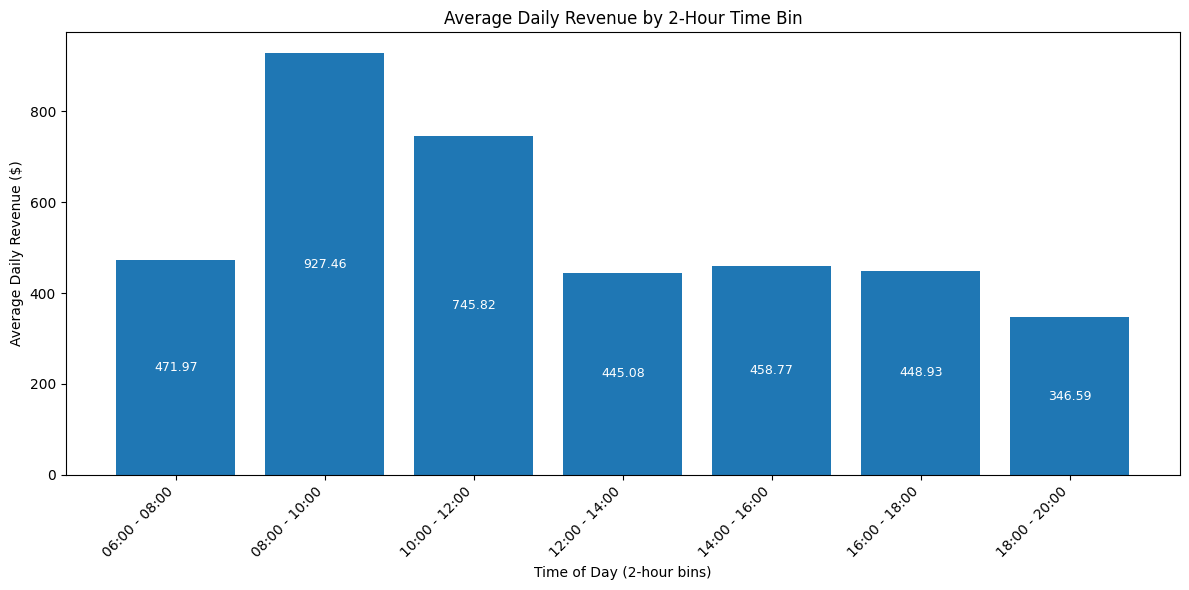

<Figure size 640x480 with 0 Axes>

In [ ]:
#histogram for every time period
import pandas as pd
import matplotlib.pyplot as plt
#df = pd.read_excel("Coffee Shop Sales.xlsx")
#make new df
time_df = df[["transaction_date","transaction_time","transaction_qty","unit_price"]].copy()
#create revenue
time_df["Revenue"] = time_df["unit_price"] * time_df["transaction_qty"]
#Change time format
time_df["transaction_time"] = pd.to_datetime(time_df["transaction_time"], format="%H:%M:%S")
time_df["Hour"] = time_df["transaction_time"].dt.hour
#create bins for every two hours
bins = range(0, 25, 2)
labels = [f"{h:02d}:00 - {h+2:02d}:00" for h in range(0, 24, 2)]
time_df["TimeBin"] = pd.cut(time_df["Hour"], bins=bins, right=False, labels=labels)
time_df = time_df[time_df["TimeBin"] != "20:00 - 22:00"]
bin_daily = (time_df.groupby(["transaction_date","TimeBin"], observed=True)["Revenue"].sum().reset_index())
avg_rev_bin = (bin_daily.groupby("TimeBin", observed=True)["Revenue"].mean().reset_index().rename(columns={"Revenue":"Avg_Daily_Revenue"}))
print(avg_rev_bin)
#Create plot
plt.figure(figsize=(12,6))
plt.bar(avg_rev_bin["TimeBin"].astype(str), avg_rev_bin["Avg_Daily_Revenue"])
plt.xticks(rotation=45, ha="right")
#make data labels
for i,v in enumerate(avg_rev_bin["Avg_Daily_Revenue"]):
    plt.text(i, v/2, f"{v:.2f}", ha="center", va="center", fontsize=9, color="white")
plt.xlabel("Time of Day (2-hour bins)")
plt.ylabel("Average Daily Revenue ($)")
plt.title("Average Daily Revenue by 2-Hour Time Bin")
plt.tight_layout()
plt.show()
plt.savefig("timebin_revenue.png", dpi=300, bbox_inches="tight")

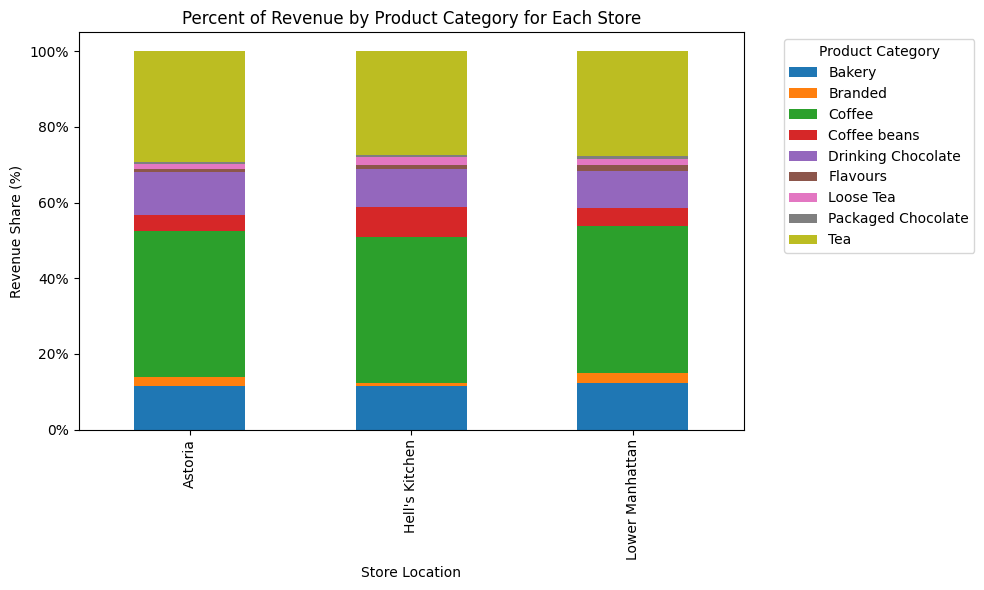

In [ ]:

from matplotlib.ticker import PercentFormatter
grouped = (
    df.groupby(["store_location", "product_category"])["Revenue"]
      .sum()
      .reset_index()
)

#Pivot so rows = store, columns = product_category, values = total revenue
pivot = grouped.pivot(
    index="store_location",
    columns="product_category",
    values="Revenue"
).fillna(0)

#Convert to percentages within each store
pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

#Plot stacked bar chart
ax = pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

#Formatting
ax.set_title("Percent of Revenue by Product Category for Each Store")
ax.set_xlabel("Store Location")
ax.set_ylabel("Revenue Share (%)")

#Show y-axis as percentages
ax.yaxis.set_major_formatter(PercentFormatter())

plt.legend(title="Product Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

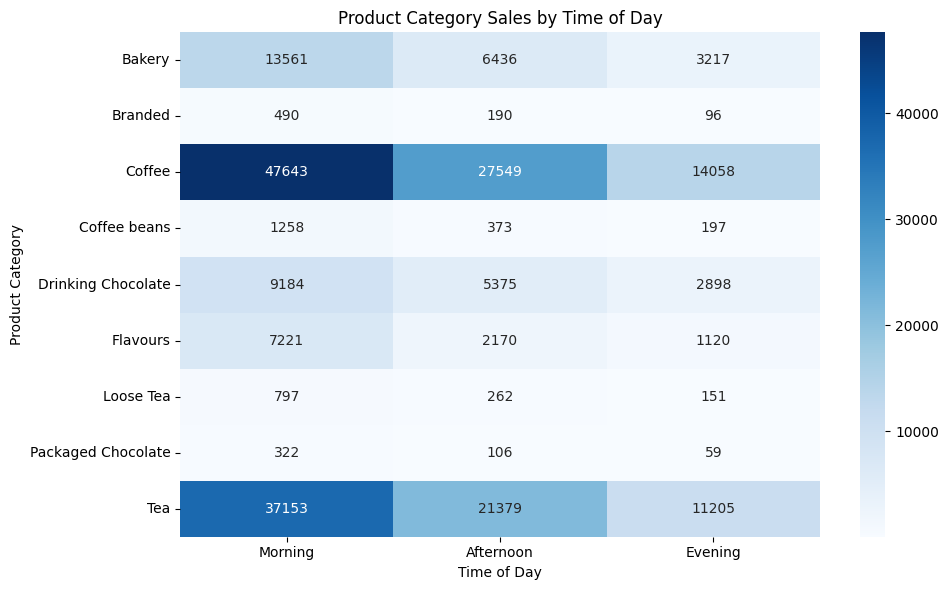

In [ ]:

#Heat map for product category sales by time of day
#label bin size again
def bucket_time(t):
    h=t.hour
    if 5<=h<12:
        return "Morning"
    elif 12<=h<17:
        return "Afternoon"
    else:
        return "Evening"

df["TimeOfDay"]=df["transaction_time"].apply(bucket_time)

grouped=df.groupby(["product_category","TimeOfDay"])["transaction_qty"].sum().reset_index()

pivot=grouped.pivot(index="product_category",columns="TimeOfDay",values="transaction_qty").fillna(0)

pivot=pivot.reindex(columns=["Morning","Afternoon","Evening"])
#create heatmap
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")
plt.title("Product Category Sales by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

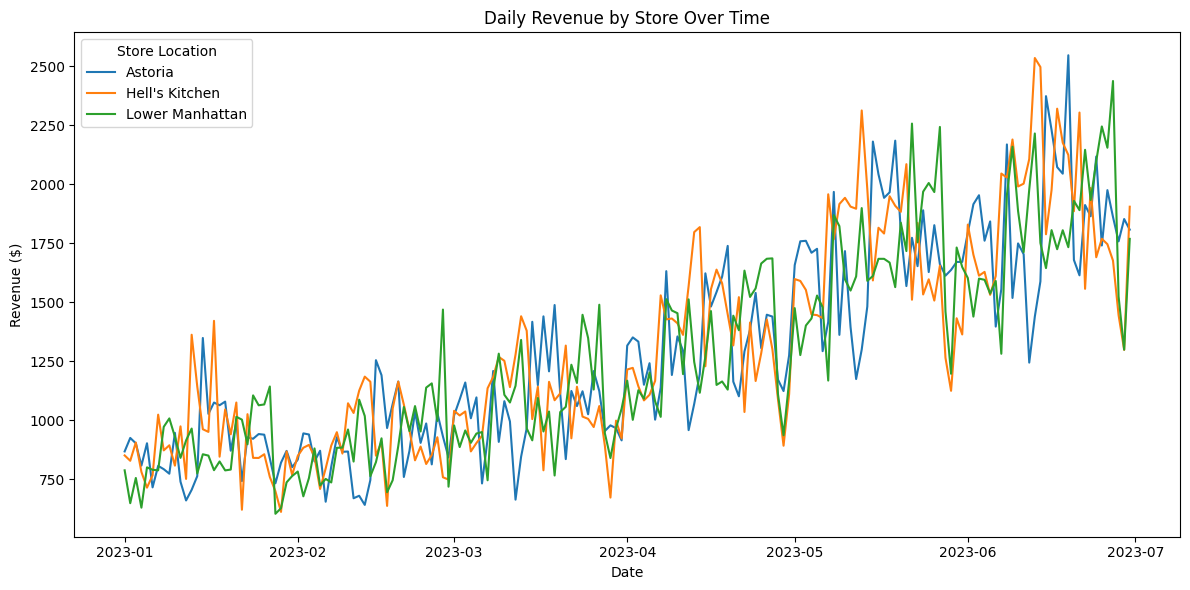

In [ ]:
df["date"]=df["transaction_date"]
#make new daily df
daily=df.groupby(["date","store_location"])["Revenue"].sum().reset_index()

pivot=daily.pivot(index="date",columns="store_location",values="Revenue").fillna(0)
#create plot
plt.figure(figsize=(12,6))
for col in pivot.columns:
    plt.plot(pivot.index,pivot[col],label=col)

plt.title("Daily Revenue by Store Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.legend(title="Store Location")
plt.tight_layout()
plt.show()

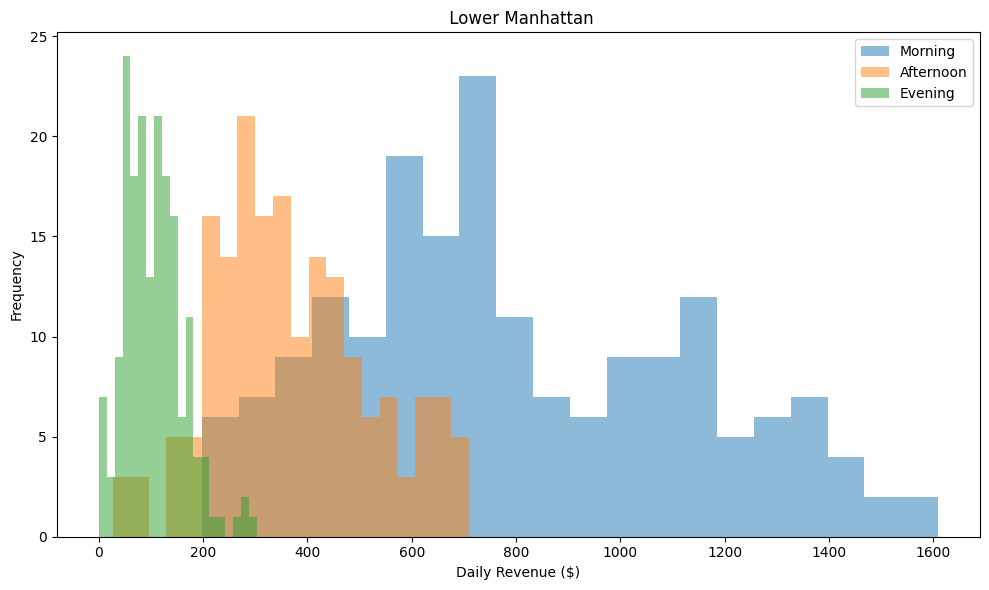

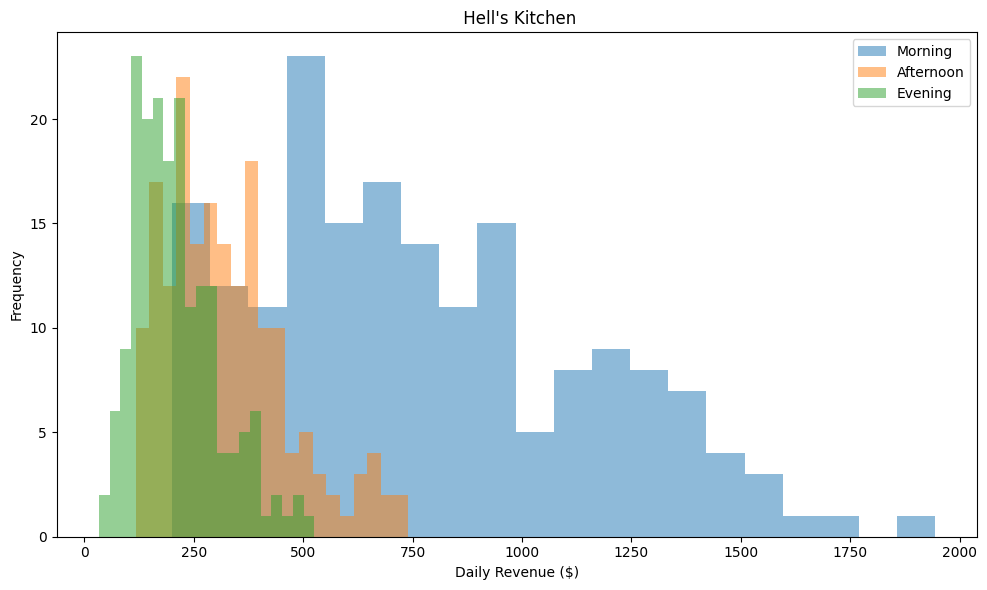

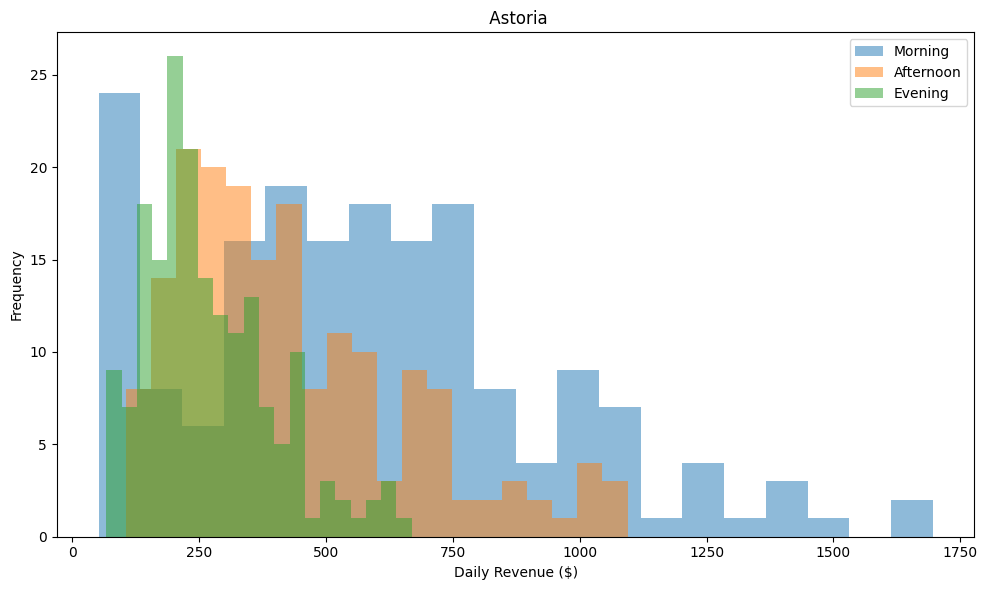

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#make sure revenue is defined
df["Revenue"]=df["unit_price"]*df["transaction_qty"]
#convert time to a time-of-day bucket
def bucket_time(t):
    h=t.hour
    if 5<=h<12:
        return "Morning"
    elif 12<=h<17:
        return "Afternoon"
    else:
        return "Evening"

df["TimeOfDay"]=df["transaction_time"].apply(bucket_time)

#aggregate daily revenue by store and time of day
daily=df.groupby(["transaction_date","store_location","TimeOfDay"])["Revenue"].sum().reset_index()

#create a pivott table
pivot=daily.pivot(index="transaction_date",columns=["store_location","TimeOfDay"],values="Revenue").fillna(0)

stores=df["store_location"].unique().tolist()

#loop over each store creating a histogram
for store in stores:
    plt.figure(figsize=(10,6))
    for tod in ["Morning","Afternoon","Evening"]:
        if (store,tod) in pivot.columns:
            plt.hist(pivot[(store,tod)],bins=20,alpha=0.5,label=tod)
    plt.title(f" {store}")
    plt.xlabel("Daily Revenue ($)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()
